In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# from ultralytics.data.converter import convert_coco

# # Вкажіть шлях до папки, де лежить ваш result.json
# convert_coco(labels_dir='./dataset/', use_segments=True)

In [3]:
# import json

# with open('dataset/result_coco.json', 'r') as f:
#     data = json.load(f)

# for image in data['images']:
#     # Прибираємо шлях і залишаємо тільки назву файлу
#     full_name = image['file_name']
#     image['file_name'] = full_name.split('/')[-1].split('_', 1)[-1] 

# with open('result_fixed.json', 'w') as f:
#     json.dump(data, f)

In [4]:
# import os

# # 1. Вкажіть шлях до папки з вашими файлами (labels або images)
# folder_path = r'C:\UnProg\DIPLOMA\coco_converted2\labels\result_coco' 

# # 2. Виберіть роздільник (зазвичай '_' для Label Studio)
# separator = '-' 

# files = os.listdir(folder_path)
# count = 0

# for filename in files:
#     if separator in filename:
#         # Розбиваємо назву на дві частини по ПЕРШОМУ роздільнику
#         # '8b2a1_my_image.txt' -> ['8b2a1', 'my_image.txt']
#         new_name = filename.split(separator, 1)[-1]
        
#         old_path = os.path.join(folder_path, filename)
#         new_path = os.path.join(folder_path, new_name)
        
#         # Перевіряємо, чи такий файл уже не існує, щоб не перезаписати його
#         if not os.path.exists(new_path):
#             os.rename(old_path, new_path)
#             count += 1
#         else:
#             print(f"Пропущено: {new_name} вже існує")

# print(f"Готово! Перейменовано файлів: {count}")

In [5]:
# from ultralytics import YOLO

# model = YOLO(".pts/yolo11n-seg.pt")

# # Вказуємо шлях до вашого YAML файлу
# model.train(
#     data="sfx_data.yaml", 
#     epochs=70, 
#     imgsz=1024,
#     workers=0
# )

In [6]:
from ultralytics import YOLO

model = YOLO("../research/runs/segment/sfx_comparison/train_y11n/weights/best.pt")


image 1/1 c:\UnProg\DIPLOMA\imgs\1.jpg: 608x640 2 sfxs, 40.2ms
Speed: 2.1ms preprocess, 40.2ms inference, 8.8ms postprocess per image at shape (1, 3, 608, 640)


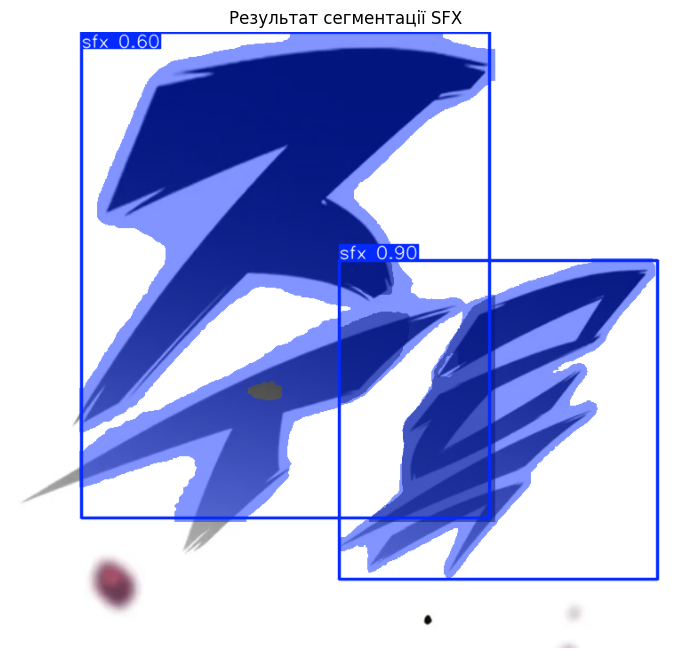

In [7]:
import matplotlib.pyplot as plt
import cv2

# 2. Отримуємо результат
img_path = "imgs/1.jpg"
results = model.predict(source=img_path, conf=0.5)
res = results[0]

# 3. Побудова зображення з масками (у форматі BGR)
plot_bgr = res.plot() 

# 4. Конвертуємо BGR в RGB для Matplotlib
plot_rgb = cv2.cvtColor(plot_bgr, cv2.COLOR_BGR2RGB)

# 5. Візуалізація
plt.figure(figsize=(12, 8))
plt.imshow(plot_rgb)
plt.axis('off') # прибрати координатні осі
plt.title("Результат сегментації SFX")
plt.show()

In [8]:
img = cv2.imread(img_path)
results = model.predict(img)[0]

# Створюємо порожню ідеальну маску для всієї сторінки
final_perfect_masks = np.zeros(img.shape[:2], dtype=np.uint8)

# Проходимось по всіх знайдених звуках
for i in range(len(results)):
    # 1. Беремо недосконалу маску від YOLO (у форматі масиву 0 і 1)
    yolo_mask = results.masks.data[i].cpu().numpy()
    yolo_mask = cv2.resize(yolo_mask, (img.shape[1], img.shape[0]))
    
    # 2. Налаштовуємо GrabCut
    # Створюємо маску для GrabCut (0 - точно фон, 1 - точно об'єкт, 2 - можливо фон, 3 - можливо об'єкт)
    gc_mask = np.zeros(img.shape[:2], np.uint8)
    
    # Кажемо: "Все, що YOLO позначила як 1 - це точно передній план (SFX)"
    # Або, якщо YOLO захоплює зайве, можна використати вашу координату ЦЕНТРУ як гарантований об'єкт
    gc_mask[yolo_mask > 0.5] = cv2.GC_PR_FGD # Можливий передній план
    
    # Використовуємо центр як 100% точну точку (ваші 99% точності!)
    box = results.boxes.xyxy[i].cpu().numpy()
    cx, cy = int((box[0] + box[2]) / 2), int((box[1] + box[3]) / 2)
    
    # Малюємо маленьке коло в центрі, кажучи, що це 100% текст
    cv2.circle(gc_mask, (cx, cy), radius=5, color=cv2.GC_FGD, thickness=-1)
    
    # Допоміжні масиви для GrabCut
    bgdModel = np.zeros((1,65),np.float64)
    fgdModel = np.zeros((1,65),np.float64)
    
    # 3. Запускаємо GrabCut (він розширить центр та маску YOLO до ідеальних країв піксель-в-піксель)
    # Запускаємо на невеликому Bbox навколо тексту, щоб було швидше
    x1, y1, x2, y2 = map(int, box)
    rect = (x1, y1, x2-x1, y2-y1)
    
    cv2.grabCut(img, gc_mask, rect, bgdModel, fgdModel, 3, cv2.GC_INIT_WITH_MASK)
    
    # 4. Витягуємо результат: беремо те, що GrabCut вважає об'єктом
    perfect_mask = np.where((gc_mask==2)|(gc_mask==0), 0, 1).astype('uint8')
    
    # Додаємо до загальної маски
    final_perfect_masks = cv2.bitwise_or(final_perfect_masks, perfect_mask)


0: 608x640 3 sfxs, 6.8ms
Speed: 2.0ms preprocess, 6.8ms inference, 3.8ms postprocess per image at shape (1, 3, 608, 640)


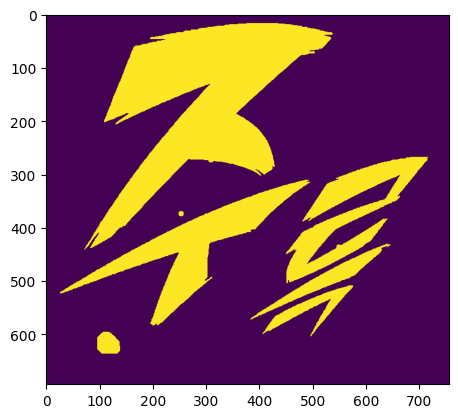

In [9]:
plt.imshow(final_perfect_masks)

In [10]:
import numpy as np
import torch

# 1. Перевіряємо, чи є маски у результаті
if res.masks is not None:
    # Отримуємо всі маски як один тензор і об'єднуємо їх (логічне "АБО")
    # Маски зазвичай мають менший розмір, ніж оригінал, тому використовуємо .xy для точного розміру
    combined_mask = torch.any(res.masks.data, dim=0).cpu().numpy()

    # 2. Масштабуємо маску до розміру оригінального зображення
    # YOLO зберігає маски у внутрішньому розширенні, тому треба розтягнути до imgs/5.jpg
    orig_h, orig_w = res.orig_shape
    mask_resized = cv2.resize(combined_mask.astype(np.uint8), 
                              (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # 3. Перетворюємо в формат 0-255 (білий - область для зміни, чорний - залишити)
    bw_mask = (mask_resized * 255).astype(np.uint8)

    # 4. Збереження
    cv2.imwrite("inpaint_mask.png", bw_mask)
    
    print("Маску збережено як inpaint_mask.png")
else:
    print("Об'єктів для маскування не знайдено.")

Маску збережено як inpaint_mask.png


True

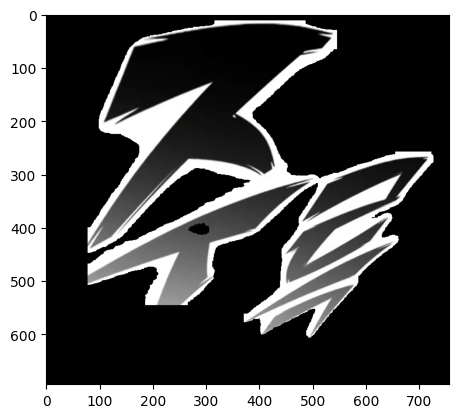

In [11]:
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
binary_mask = (bw_mask > 0).astype("uint8")
blank = image * binary_mask[:, :, np.newaxis]
plt.imshow(blank.clip(0, 255).astype("uint8"))
imwerite_image_after_mask = blank.clip(0, 255).astype("uint8")
cv2.imwrite("masked_image.png", cv2.cvtColor(imwerite_image_after_mask, cv2.COLOR_RGB2BGR))

In [12]:
len(results[0].masks)

1

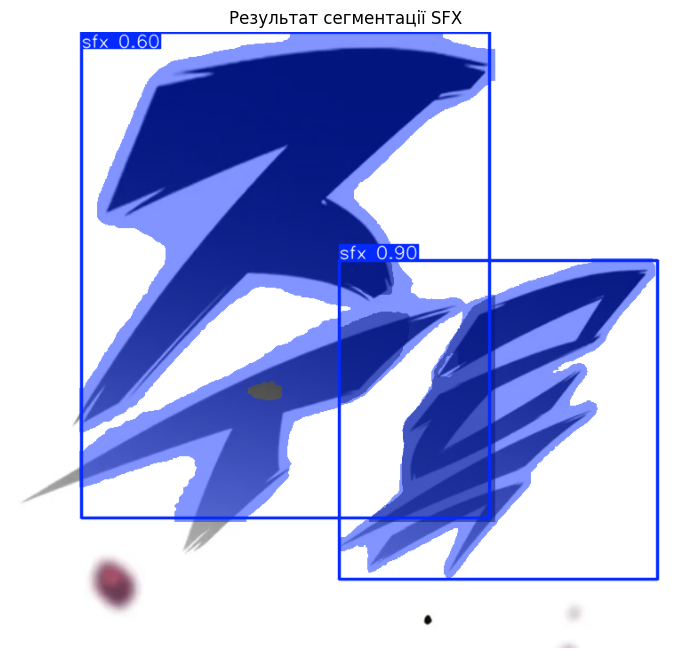

In [13]:
plt.figure(figsize=(12, 8))
plt.imshow(plot_rgb)
plt.axis('off') # прибрати координатні осі
plt.title("Результат сегментації SFX")
plt.show()

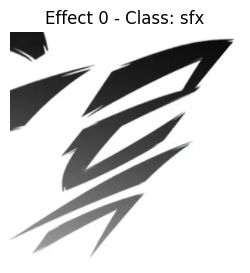

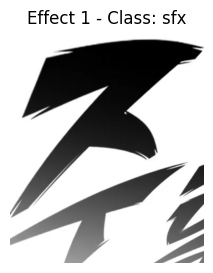

In [14]:
import cv2
import matplotlib.pyplot as plt

img = res.orig_img  # Оригінальне зображення

# Проходимо по всіх знайдених боксах
for i, box in enumerate(res.boxes):
    # Отримуємо координати (x1, y1, x2, y2)
    xyxy = box.xyxy[0].cpu().numpy().astype(int)
    x1, y1, x2, y2 = xyxy
    
    # Обрізаємо зображення по координатах
    crop = img[y1:y2, x1:x2]
    
    # Відображаємо
    plt.figure(figsize=(3, 3))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Effect {i} - Class: {res.names[int(box.cls[0])]}")
    plt.axis('off')
    plt.show()

In [15]:
def merge_bboxes(bboxes):
    # bboxes - це список або масив [[x1, y1, x2, y2], ...]
    if hasattr(bboxes, 'cpu'):
        bboxes = bboxes.cpu().numpy()
    else:
        bboxes = np.array(bboxes)
    
    if len(bboxes) == 0:
        return None
    
    x_min = np.min(bboxes[:, 0])
    y_min = np.min(bboxes[:, 1])
    x_max = np.max(bboxes[:, 2])
    y_max = np.max(bboxes[:, 3])
    
    return [x_min, y_min, x_max, y_max]

In [16]:
merge_bboxes(results[0].boxes.xyxy)

[np.float32(370.3052),
 np.float32(257.40833),
 np.float32(728.7139),
 np.float32(616.96906)]

In [17]:
def get_centers(bboxes):
    centers = []
    if hasattr(bboxes, 'cpu'):
        bboxes = bboxes.cpu().numpy()
    else:
        bboxes = np.array(bboxes)
    
    if len(bboxes) == 0:
        return None
    
    for box in bboxes:
        x_center = (box[0] + box[2]) / 2
        y_center = (box[1] + box[3]) / 2
        centers.append([x_center, y_center])
    return np.array(centers)

In [18]:
get_centers(results[0].boxes.xyxy)

array([[     549.51,      437.19]], dtype=float32)

In [19]:
from sklearn.linear_model import LinearRegression

def get_regression_line(centers):
    # X - це координати x, y - цільова змінна
    X = centers[:, 0].reshape(-1, 1)
    y = centers[:, 1]
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Коефіцієнт нахилу (k) та вільний член (b)
    k = model.coef_[0]
    b = model.intercept_
    
    return k, b

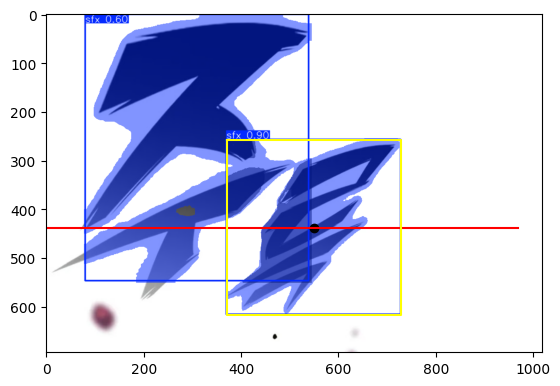

In [20]:
t = np.linspace(0, 970, 100)
regr = get_regression_line(get_centers(results[0].boxes.xyxy))
plt.imshow(plot_rgb)
plt.plot(t, regr[0]*t + regr[1], color="red")
plt.scatter(get_centers(results[0].boxes.xyxy)[..., 0], get_centers(results[0].boxes.xyxy)[..., 1], color="black")

big_box = merge_bboxes(results[0].boxes.xyxy)
box_plot = np.array([[big_box[0], big_box[1]], 
                     [big_box[2], big_box[1]], 
                     [big_box[2], big_box[3]], 
                     [big_box[0], big_box[3]], 
                     [big_box[0], big_box[1]]])

plt.plot(box_plot[..., 0], box_plot[..., 1], color="yellow")
